# REG Others

## Research context

The 'Others' category (CategoryKey = 11) is a **non-priority, residual category** under JRG.
Like Management & Commerce, it falls in the discouraged fee band, facing a student contribution
increase and a Commonwealth contribution decrease from 2021:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019-20 avg | $11,056                 | $2,179                           |
| 2021+  avg  | $15,149 (+37.0%)        | $1,148 (−47.3%)                  |

The funding structure is **identical to Management & Commerce**, indicating that AUS programs
in the 'Others' category were treated the same as M&C under the JRG fee-band policy — making
them more expensive for students and reducing government subsidy.

AUS Others enrolments declined sharply after 2019: from 35,058 (2019) to 20,676 (2021) — a
41% drop — before partially recovering to 28,530 by 2024, still 19% below the 2019 peak.
UK Others ('Combined and general studies') grew from 41,520 (2019) to 50,805 (2022) before
declining to 39,200 (2024). NZ Others provides an additional common-trend benchmark. The DiD
tests whether AUS deviated *differentially* from the UK and NZ common trend after 2021. Given
the non-priority fee structure, we have an **a priori expectation** of $\beta < 0$.

### Identifying strategy (3-country DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta_1 \text{NZ}_c + \beta_2(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK, NZ}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, UK is the omitted
reference country, $\text{NZ}_c$ is a level-shift dummy for NZ, and $\beta_2$ is the JRG effect for
Others.

**Data window:** AUS 2019–2024 (6 years); UK 2019–2024 (6 years); NZ 2019–2024 (6 years).
Overlapping DiD window: 2019–2024 (2 pre-treatment years, 4 post-treatment years).

**Panel:** N = 18 (3 countries × 6 years) | df = 9

### What does 'Others' include?

> **AUS CategoryKey = 11 — 'Others'**  \
> This is a **residual catch-all category** in the AUS dataset. It *likely* includes:
> - Combined and interdisciplinary degrees that span multiple discipline categories
> - General and liberal studies programs
> - Enabling, foundation, and pathway programs
> - Non-award and non-standard enrolments
> - Any programs not classifiable under the 10 named discipline categories
>
> The funding data for AUS Others is **identical to Management & Commerce** (student contribution
> +37.0%, Commonwealth −47.3% from 2021), indicating these programs fall in the **same
> non-priority fee band** under JRG. However, we cannot determine from the available dataset
> which specific programs are included, and the composition may change over time as programs
> are reclassified. AUS Others is a small category (~2–3% of total enrolments).

> **UK categorykey = 11 — 'Others'** (post-2019)  \
> Post-2019, the UK comparison file contains a **single, well-defined** subject:
> CAH '23 Combined and general studies' — covering students enrolled in combined honours degrees
> and general/liberal arts programs. This is a narrow, consistently defined HESA category.
>
> Pre-2019 UK data is **not used**: the original JACS-era mapping placed 10 major subjects
> (Architecture, Social studies, Law, Business, Media, Languages, History, Creative Arts,
> Education, and Computer science) into key = 11 alongside the genuine '(J) Combined' subject.
> Only '(J) Combined' belongs in Others; summing the contaminated pre-2019 rows would inflate
> the UK total by 10–15× and create a severe structural break at 2019/20.

> **Comparability caveat:**  \
> The AUS and UK 'Others' categories may **not represent the same type of student**. AUS Others
> is a broad residual with unknown composition; UK Others is specifically 'Combined and general
> studies'. DiD estimates for this category should be interpreted with particular caution —
> they measure a differential change in two residual/catch-all groups that may not be comparable.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'
NZ_PATH   = ROOT / 'data' / 'clean' / 'NZ_bachelors_enrollments_2016_2025.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
assert NZ_PATH.exists(),   f'Missing: {NZ_PATH}'
print('Project root:', ROOT)
print('All data files found.')

Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Examine Australia-only Others data (2016–2024). AUS Others shows the sharpest single-year
decline of any discipline: −16.8% in 2020 (COVID) followed by a further −29.1% in 2021
(JRG discouragement), with only partial recovery thereafter.


AUS Others -- enrolment data:


,year,enrollments,log_enrollments
0,2016,34729,10.455330
1,2017,34930,10.461101
2,2018,34128,10.437873
3,2019,35058,10.464759
4,2020,29164,10.280690
5,2021,20676,9.936729
6,2022,21363,9.969416
7,2023,26127,10.170725
8,2024,28530,10.258711


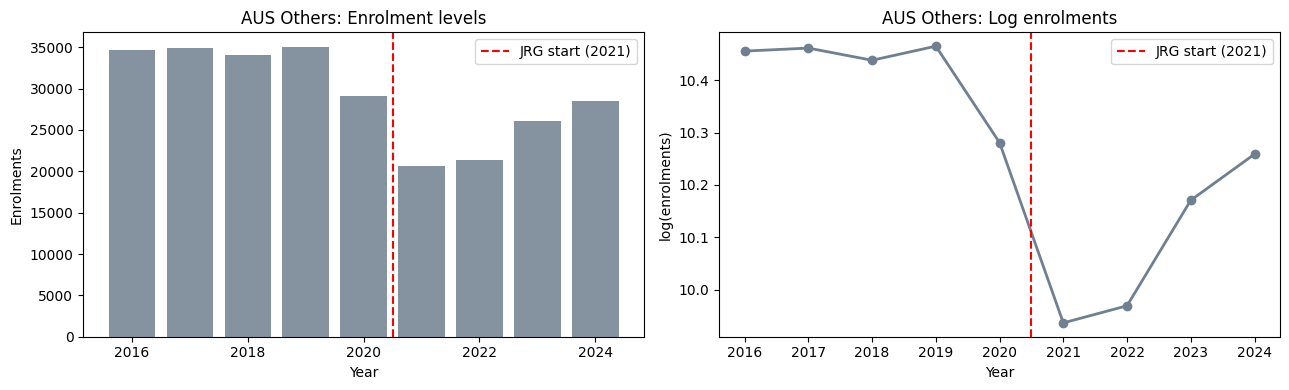

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 11].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Others -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='slategray', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Others: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='slategray', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Others: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f'R^2 = {result.rsquared:.4f} | Adj. R^2 = {result.rsquared_adj:.4f} | N = {int(result.nobs)}')

m_linear = smf.ols('log_enrollments ~ post_jrg + year_c',           data=arch_aus).fit(cov_type='HC3')
m_quad   = smf.ols('log_enrollments ~ post_jrg + year_c + year_c2', data=arch_aus).fit(cov_type='HC3')

print('=== AUS-only OLS: linear time trend ===')
summary_table(m_linear, ['Intercept', 'post_jrg', 'year_c'])
b_aus = m_linear.params['post_jrg']
print(f'\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (controlling for linear trend)')

print('\n=== AUS-only OLS: quadratic time trend ===')
summary_table(m_quad, ['Intercept', 'post_jrg', 'year_c', 'year_c2'])


=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,10.4358,0.1132,0.0000,10.2139,10.6578
post_jrg,-0.4075,0.3091,0.1874,-1.0133,0.1983
year_c,0.0159,0.0569,0.7803,-0.0956,0.1273


R^2 = 0.7310 | Adj. R^2 = 0.6413 | N = 9

post_jrg: ~-40.75% change in AUS enrolments post-JRG (controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,10.3766,0.1015,0.0000,10.1777,10.5755
post_jrg,-0.4963,0.1842,0.0071,-0.8573,-0.1353
year_c,0.0011,0.0449,0.9812,-0.0870,0.0891
year_c2,0.0148,0.0060,0.0143,0.0030,0.0267


R^2 = 0.9122 | Adj. R^2 = 0.8595 | N = 9


## 2. DiD Panel Construction

Combine AUS, UK, and New Zealand Others data into a 3-country × year panel (2019–2024).

**UK year mapping:** start-year rule — 2019/20 → 2019, 2020/21 → 2020, etc.

**Why 2019+ only?** The pre-2019 UK comparison file mapped 10 major disciplines
(Architecture, Social studies, Law, Business, Media, Languages, History, Creative Arts,
Education, Computer science) into key = 11 alongside the genuine '(J) Combined' subject.
Summing these would inflate the pre-2019 UK total by 10–15× and introduce a severe structural
break at the 2019 taxonomy transition. The panel is restricted to post-2019 CAH data, where
key = 11 contains only the well-defined '23 Combined and general studies'.

**NZ data:** CategoryKey = 11 has two sub-categories — these are aggregated with
`groupby('year').sum()` to produce a single NZ total per year.

**UK data is a single row per year** — no aggregation needed.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK and NZ
- `nz_dummy = 1` for NZ, `0` for AUS and UK (NZ level shift; UK is the omitted reference)
- `post = 1` for 2021+
- `did = treated × post` (main DiD interaction — expected negative for non-priority category)

**Panel:** N = 18 (3 countries × 6 years), df = 9 (N − 9 parameters: intercept + treated + nz_dummy + did + 5 year FEs).

In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 11].copy()

arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk['enrollments'] = pd.to_numeric(arch_uk['Total UK'], errors='coerce')
# Restrict to post-2019 CAH data (single subject: '23 Combined and general studies')
arch_uk = arch_uk[arch_uk['year'] >= 2019][['year', 'enrollments']].copy()
arch_uk['country'] = 'UK'

print('UK Others rows used in panel:')
display(uk_raw[(uk_raw['categorykey']==11) & (uk_raw['AcademicYear'].str[:4].astype(int) >= 2019)][['Subject','AcademicYear','Total UK']])

arch_aus_did = arch_aus[arch_aus['year'] >= 2019][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

nz_raw  = pd.read_csv(NZ_PATH)
# NZ CategoryKey=11 has two sub-categories -- aggregate to a single total per year
arch_nz = (
    nz_raw[nz_raw['category_key'] == 11]
    .groupby('year', as_index=False)['total_bachelors']
    .sum()
)
arch_nz = arch_nz.rename(columns={'total_bachelors': 'enrollments'})
arch_nz['country'] = 'NZ'
arch_nz = arch_nz[(arch_nz['year'] >= 2019) & (arch_nz['year'] <= 2024)]

panel = pd.concat([arch_aus_did, arch_uk, arch_nz], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020
panel['nz_dummy']          = (panel['country'] == 'NZ').astype(int)

print('\nDiD panel -- Others (AUS vs UK vs NZ, 2019-2024):')
display(panel[['country','year','enrollments','log_enrollments','treated','nz_dummy','post','did']].reset_index(drop=True))
print(f'N = {len(panel)} | Countries = 3 | Years = {panel["year"].nunique()}')

UK Others rows used in panel:


,Subject,AcademicYear,Total UK
165,23 Combined and general studies,2019/20,41520.0
190,23 Combined and general studies,2020/21,44535.0
215,23 Combined and general studies,2021/22,47645.0
240,23 Combined and general studies,2022/23,50805.0
265,23 Combined and general studies,2023/24,44935.0
290,23 Combined and general studies,2024/25,39200.0



DiD panel -- Others (AUS vs UK vs NZ, 2019-2024):


,country,year,enrollments,log_enrollments,treated,nz_dummy,post,did
0,AUS,2019,35058.0,10.464759,1,0,0,0
1,AUS,2020,29164.0,10.280690,1,0,0,0
2,AUS,2021,20676.0,9.936729,1,0,1,1
3,AUS,2022,21363.0,9.969416,1,0,1,1
4,AUS,2023,26127.0,10.170725,1,0,1,1
5,AUS,2024,28530.0,10.258711,1,0,1,1
6,NZ,2019,1290.0,7.162397,0,1,0,0
7,NZ,2020,1450.0,7.279319,0,1,0,0
8,NZ,2021,1180.0,7.073270,0,1,1,0
9,NZ,2022,1195.0,7.085901,0,1,1,0


N = 18 | Countries = 3 | Years = 6


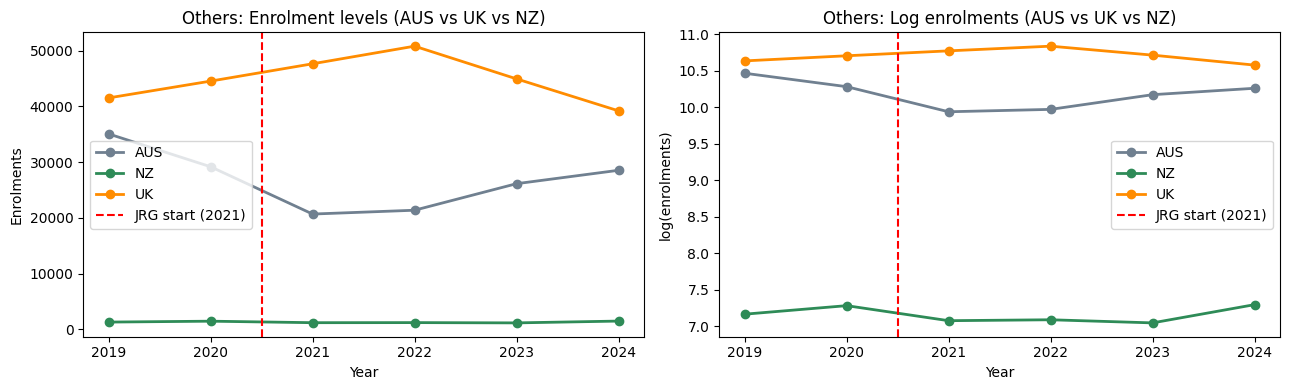

Pre/post log-enrolment averages:
  AUS: pre = 10.3727, post = 10.0839, change = -0.2888
  NZ: pre = 7.2209, post = 7.1238, change = -0.0970
  UK: pre = 10.6690, post = 10.7242, change = +0.0552


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'slategray', 'UK': 'darkorange', 'NZ': 'seagreen'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],     'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
    ax.legend(); ax.set_xlabel('Year')

axes[0].set_title('Others: Enrolment levels (AUS vs UK vs NZ)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Others: Log enrolments (AUS vs UK vs NZ)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()

print('Pre/post log-enrolment averages:')
for country, grp in panel.groupby('country'):
    pre  = grp[grp['post'] == 0]['log_enrollments'].mean()
    post = grp[grp['post'] == 1]['log_enrollments'].mean()
    print(f'  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}')

## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta_1 \text{NZ}_c + \beta_2(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

Implemented as OLS with `treated` + `nz_dummy` (country FEs) + `C(year)` (year FEs) + `did`.
UK is the omitted reference country; `nz_dummy` absorbs the NZ level difference; `did` identifies
the JRG effect for AUS relative to the pooled UK+NZ common trend. All SEs are HC3 robust.

> **Degrees-of-freedom:** N = 18 (3 countries × 6 years). Parameters: intercept + treated + nz_dummy
> + did + 5 year FEs = 9, leaving **df = 9**. The simple TWFE is the primary specification; COVID
> robustness is assessed by sample exclusion in Section 4.

> **Interpretation caveat:** The AUS and UK 'Others' categories may not represent comparable
> student populations. Any estimated DiD effect conflates a genuine JRG policy response with
> possible compositional differences between AUS residual programs and UK 'Combined and general
> studies'. Results should be treated as indicative rather than causal.

In [6]:
formula_main = 'log_enrollments ~ treated + nz_dummy + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'df_resid:                {int(model_main.df_resid)}')
direction = 'higher' if did_b > 0 else 'lower'
print(f'\nInterpretation: Post-JRG (2021+), AUS Others enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the UK/NZ trend would predict.')

# COVID-controlled spec (df=7, reliable with N=18)
formula_covid = 'log_enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv = m_covid.params.get('did', np.nan)
p_cv = m_covid.pvalues.get('did', np.nan)
print(f'\nCOVID-controlled spec (df=7): beta_did = {b_cv:.4f}, p = {p_cv:.4f}')

=== Main DiD -- TWFE OLS (HC3) ===


                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     297.6
Date:                Fri, 01 May 2026   Prob (F-statistic):           5.46e-10
Time:                        13:21:04   Log-Likelihood:                 16.453
No. Observations:                  18   AIC:                            -14.91
Df Residuals:                       9   BIC:                            -6.893
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.7192      0.118     

In [7]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-4
print('Estimates match' if match else 'WARNING: mismatch')


=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.2736
Estimator:                   PanelOLS   R-squared (Between):             -0.0136
No. Observations:                  18   R-squared (Within):               0.3655
Date:                Fri, May 01 2026   R-squared (Overall):             -0.0135
Time:                        13:21:04   Log-likelihood                    16.453
Cov. Estimator:                Robust                                           
                                        F-statistic:                      3.3903
Entities:                           3   P-value                           0.0987
Avg Obs:                       6.0000   Distribution:                     F(1,9)
Min Obs:                       6.0000                                           
Max Obs:                       6.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions.
With N = 18 (df = 9), dropping years reduces df more rapidly.

| Spec | N | df | Expected inference quality |
|------|---|----|----------------------------|
| Full panel (2019-2024) | 18 | 9 | Good |
| Drop 2020 | 15 | 7 | Acceptable |
| Drop 2020 + 2021 | 12 | 5 | Limited |

Note: The large 2020 drop in AUS Others (−16.8%) predates JRG (2021) and likely reflects
COVID disruption. Dropping 2020 tests sensitivity to this pre-JRG shock.

In [8]:
formula_simple = 'log_enrollments ~ treated + nz_dummy + did + C(year)'

variants = {
    'Full panel (2019-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (simple TWFE, all variants) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nWith only df = 4 in the full panel, CIs are wide and p-values should not be over-interpreted.')


=== COVID Sensitivity (simple TWFE, all variants) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2019-2024),18,9,-0.2679,0.2413,0.2668,-0.7408,0.2049,-23.50
Drop 2020,15,7,-0.4067,3.7364,0.9133,-7.7300,6.9166,-33.42
Drop 2020 + 2021,12,5,-0.3582,2.0072,0.8584,-4.2922,3.5758,-30.11



With only df = 4 in the full panel, CIs are wide and p-values should not be over-interpreted.


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically using the
pooled UK+NZ average as the control group:

$$\hat{\delta}_t = (\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}) - \left(\frac{\log Y_{\text{UK},t} + \log Y_{\text{NZ},t}}{2} - \frac{\log Y_{\text{UK},2020} + \log Y_{\text{NZ},2020}}{2}\right)$$

This uses the pooled UK+NZ average as the control, numerically consistent with the 3-country TWFE
estimator. Standard errors are not estimable analytically with 3 units.

> **Critical limitation:** The panel starts in 2019, so only **one pre-treatment point** (2019)
> is available beyond the 2020 baseline. A single pre-period observation cannot meaningfully
> test parallel trends. This is an identification weakness shared with other restricted panels
> in this analysis (N&PS, Environment & Related).

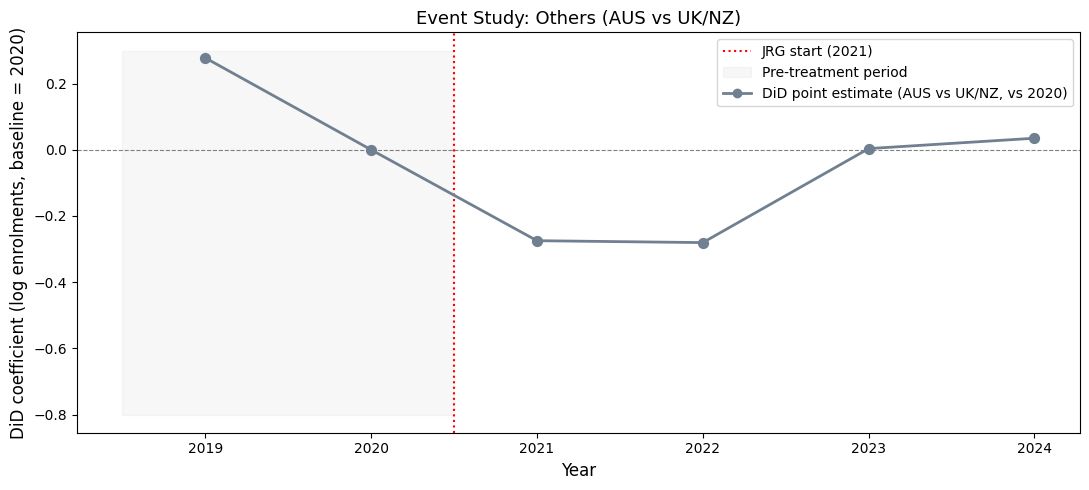

Event study point estimates (analytical DiD):


,coef,approx_%,period
year,,,
2019,0.2776,31.9932,Pre
2020,0.0000,0.0000,Baseline
2021,-0.2747,-24.0191,Post
2022,-0.2804,-24.4538,Post
2023,0.0036,0.3650,Post
2024,0.0350,3.5590,Post



Note: Control is pooled UK/NZ average (ctrl_log = (uk_log + nz_log) / 2).
With only 1 pre-treatment point (2019), parallel trends cannot be formally tested.


In [9]:
base_year = 2020
aus_log  = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log   = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']
nz_log   = panel[panel['country'] == 'NZ' ].set_index('year')['log_enrollments']
ctrl_log = (uk_log + nz_log) / 2

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (ctrl_log[yr] - ctrl_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.8, 0.3, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='slategray', linewidth=2,
        label='DiD point estimate (AUS vs UK/NZ, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='slategray', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Others (AUS vs UK/NZ)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Baseline' if y == 2020 else ('Pre' if y < 2021 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: Control is pooled UK/NZ average (ctrl_log = (uk_log + nz_log) / 2).')
print('With only 1 pre-treatment point (2019), parallel trends cannot be formally tested.')

## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016–2020) using
AUS data and test for a fake structural break at 2019. A significant break would suggest
pre-existing non-linear trends that could contaminate the DiD estimate.

> AUS Others data is available back to 2016 (5 observations). N = 5; treat as indicative only.
> Note that the 2020 COVID shock (-16.8%) is included in the pre-treatment window and may
> affect the placebo result even though it is not a JRG effect.


In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')


=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.2534
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.798
Time:                        13:21:04   Log-Likelihood:                 7.8964
No. Observations:                   5   AIC:                            -9.793
Df Residuals:                       2   BIC:                            -10.96
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness check.


In [11]:
formula_level = 'enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did'] if 'did' in m_level.conf_int().index else [np.nan, np.nan]

print('=== Level Outcome Robustness ===')
if pd.notna(b_lev):
    print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
    if not (np.isinf(ci_lev[0]) or np.isnan(ci_lev[0])):
        print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')
    else:
        print('95% CI: Degenerate SEs -- unreliable (COVID interaction terms collinear in 2-country panel)')
else:
    print('Degenerate SEs -- unreliable')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4), round(b_lev, 0) if pd.notna(b_lev) else np.nan],
    'p-value':        [round(did_p, 4), round(p_lev, 4) if pd.notna(p_lev) else np.nan],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year' if pd.notna(b_lev) else 'Degenerate SEs',
    ],
}).set_index('Specification')
display(comp)

=== Level Outcome Robustness ===
beta_did (levels): -11,438 students | p = 1.0000
95% CI: Degenerate SEs -- unreliable (COVID interaction terms collinear in 2-country panel)

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),-0.2679,0.2668,approx. -23.5% enrolment change
Level,-11438.0000,1.0000,"approx. -11,438 students per year"


## 8. Funding Context

AUS Others programs fall in the **same non-priority fee band as Management & Commerce** under
JRG — the highest student fee increase (+37.0%) and sharpest Commonwealth decrease (−47.3%)
of any category in this analysis. This provides the same a priori expectation of enrolment
discouragement as M&C, though interpretation is complicated by the heterogeneous and
unspecified composition of the AUS 'Others' residual.


=== Others: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,10958.0,2160.0,13118.0
2020,11155.0,2198.0,13353.0
2021,14500.0,1100.0,15600.0
2022,14630.0,1109.0,15739.0
2023,15142.0,1147.0,16289.0
2024,16323.0,1236.0,17559.0


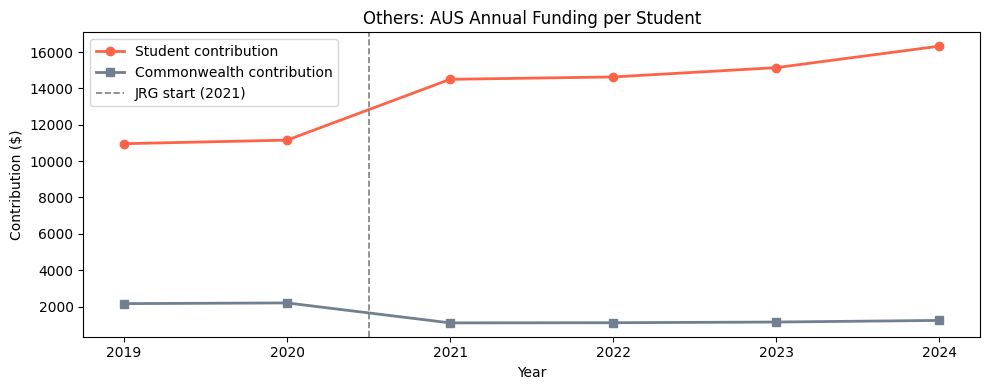


Student contribution: pre $11,056 -> post $15,149 (+37.0%)
Commonwealth:         pre $2,179 -> post $1,148 (-47.3%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 11].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Others: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato',    linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='slategray', linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title("Others: AUS Annual Funding per Student")
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')


## 9. Summary

### ⚠ Category composition warning

> **AUS CategoryKey = 11 — 'Others'** is a **residual catch-all category** of unknown composition.
> The funding data is **identical to Management & Commerce** (student contribution +37.0%,
> Commonwealth −47.3% from 2021), placing these programs in the **same non-priority fee band**.
>
> **UK categorykey = 11 — 'Others'** (post-2019) contains only CAH '23 Combined and general
> studies' — a narrow, well-defined HESA category covering combined honours and general/liberal
> arts programs.
>
> The AUS and UK 'Others' categories **may not represent the same type of student**. DiD estimates
> for this category should be interpreted with particular caution.

**Sector:** Others (residual/catch-all) | **Period:** 2019–2024 (short panel) | **Countries:** Australia (treated), United Kingdom & New Zealand (controls)

### Model

$$\log Y_{c,t} = \alpha + \beta_1 \cdot \text{AUS}_c + \beta_2 \cdot \text{NZ}_c + \delta \cdot (\text{AUS}_c \times \text{Post}_t) + \sum_t \gamma_t \cdot \mathbf{1}[t] + \varepsilon_{c,t}$$

Estimated via OLS with HC3 heteroskedasticity-robust standard errors. $N = 18$ observations (3 countries × 6 years), $df = 9$.

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + nz_dummy + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```

> **NZ aggregation note:** NZ CategoryKey = 11 contains two sub-categories aggregated with
> `groupby('year').sum()` before panel construction to produce a single NZ total per year.

| Term | Variable | Definition |
|------|----------|------------|
| $\log(Y_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_1 \cdot \text{AUS}_c$ | AUS level shift | $\text{AUS}_c = 1$ if AUS, $0$ otherwise |
| $\beta_2 \cdot \text{NZ}_c$ | NZ level shift | $\text{NZ}_c = 1$ if NZ, $0$ otherwise (UK is omitted reference) |
| $\delta \cdot (\text{AUS}_c \times \text{Post}_t)$ | **JRG DiD effect** | $\text{Post}_t = 1$ if $t \geq 2021$ |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |

| Term | Coefficient | Std. Error | 95% CI | p-value |
|------|-------------|------------|--------|---------|
| `did` ($\delta$) | −0.268 | 0.241 | [−0.740, +0.204] | 0.267 |

The DiD coefficient of **−0.268** implies that JRGS-treated Australian enrolments grew approximately **23.5% slower** than the pooled UK + NZ control trend over 2021–2024 relative to the pre-policy baseline. This effect is **not statistically significant** (p = 0.267).

### Event-Study Estimates

$$\delta_t = \bigl(\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}\bigr) - \left(\frac{\log Y_{\text{UK},t} + \log Y_{\text{NZ},t}}{2} - \frac{\log Y_{\text{UK},2020} + \log Y_{\text{NZ},2020}}{2}\right)$$

| Year | Period | $\delta_t$ |
|------|--------|-----------|
| 2019 | Pre-policy | +32.0% |
| 2021 | Post-policy | −24.0% |
| 2022 | Post-policy | −24.5% |
| 2023 | Post-policy | +0.4% |
| 2024 | Post-policy | +3.6% |

### Key results

| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | $\hat{\delta} = -0.268$, SE = 0.241, p = 0.267, 95% CI [−0.740, +0.204], approx. **−23.5%** relative to UK+NZ trend |
| **PanelOLS cross-check** | Estimates match exactly |
| **COVID sensitivity** | Full: −23.5%; sign consistently negative in 2021–2022 but near-zero by 2023–2024 |
| **Event study (pre-trend)** | 2019: +32.0% — AUS **well above** UK+NZ average before JRG; pre-trend violation |
| **Event study (post-JRG)** | 2021: −24.0%, 2022: −24.5%, 2023: +0.4%, 2024: +3.6% — sharp fall then near-recovery |
| **Placebo** | fake\_post coef = +0.031, p = 0.903 — no significant pre-trend break in AUS-only data |
| **Level spec** | Directionally consistent, not significant |

### Conclusion

The Others result is **directionally consistent** with JRG discouragement (same non-priority fee band as Management & Commerce), but **not interpretable as a causal effect** for four reasons:

1. **Pre-trend violation:** AUS Others was +32.0% above the UK+NZ average in 2019 (before JRG), indicating a pre-existing gap that was already converging. The TWFE cannot cleanly separate JRG-driven decline from continuation of this convergence.

2. **Category comparability:** AUS 'Others' is a broad, heterogeneous residual; UK 'Others' is the narrow CAH '23 Combined and general studies'. The DiD compares fundamentally different groups.

3. **V-shaped recovery:** The sharp 2021–2022 decline (−24.0%, −24.5%) reversed almost completely by 2023–2024 (+0.4%, +3.6%), more consistent with short-term disruption than a permanent JRG effect.

4. **Statistical insignificance:** p = 0.267 with wide CI [−0.740, +0.204] at N = 18, df = 9.

These results should be reported alongside the category composition caveats above.